In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from Grid import grid_generation, get_masked_grid_points, classify_grid_points, visualise_classified_grid_points

Grid size (average x difference): 88.29124953196677


c:\Users\Alex Miao\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Alex Miao\.pyenv\pyenv-win\versions\3.13.5\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Avg of 10 smallest: 186.5
Avg of 10 largest: 194.8
Difference: 8.300000000000011
Avg of 10 smallest: 186.1
Avg of 10 largest: 191.6
Difference: 5.5
Avg of 10 smallest: 186.9
Avg of 10 largest: 191.0
Difference: 4.099999999999994
Avg of 10 smallest: 189.9
Avg of 10 largest: 194.8
Difference: 4.900000000000006
Wire passes through these borders:
No border detected with wire passing through.
Avg of 10 smallest: 189.0
Avg of 10 largest: 194.5
Difference: 5.5
Avg of 10 smallest: 187.0
Avg of 10 largest: 193.5
Difference: 6.5
Avg of 10 smallest: 191.6
Avg of 10 largest: 196.1
Difference: 4.5
Avg of 10 smallest: 111.1
Avg of 10 largest: 196.7
Difference: 85.6
Wire passes through these borders:
- right
Avg of 10 smallest: 180.4
Avg of 10 largest: 188.6
Difference: 8.199999999999989
Avg of 10 smallest: 188.7
Avg of 10 largest: 192.3
Difference: 3.6000000000000227
Avg of 10 smallest: 107.6
Avg of 10 largest: 193.5
Difference: 85.9
Avg of 10 smallest: 103.5
Avg of 10 largest: 192.3
Difference: 88.

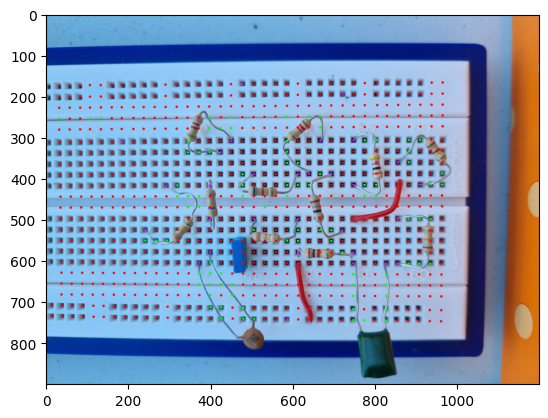

In [2]:
# Choose an image path
image_path = "./bb5.jpg"


im = cv2.imread(image_path)

# Run Grid generation
grid_img, intersections, grid_size, row_count, col_count = grid_generation(im)

plt.imshow(cv2.cvtColor(grid_img, cv2.COLOR_BGR2RGB))

# get image dimensions
height, width = im.shape[:2]

gps = classify_grid_points(im, intersections, grid_size, height, width)

class_grid_im = visualise_classified_grid_points(im, gps)
plt.imshow(cv2.cvtColor(class_grid_im, cv2.COLOR_BGR2RGB))

# Dijkstra to connect each Plugged GridPoint to Masked GridPoint 

## Create Graph

In [3]:
# Use python library for Dijkstra
from dijkstar import Graph, find_path

In [4]:
# Createa a Map with key as Grid Coordinate and Value being Grid Point Object
grid_map = {}
# Find the list of Grid Points that are plugged in
plugged_gps = []
for gp in gps:
    grid_map[gp.get_index()] = gp
    if gp.is_plugged():
        plugged_gps.append(gp)

In [5]:
# Debug print some example Grid Points
print("Example Grid Points:")
print(gps[0].get_index())
print(grid_map[(7,1)])

Example Grid Points:
(0, 1)
GP of type 0 at Point on row 7, col 1 of (114.21326612108284, 1214.913124682208) with probs [0.88893825 0.01171388 0.09934789] and borders ([], []), masked: False


In [11]:
# Manually mask some grid point for testing
grid_map[(3,14)].set_is_masked(True, "res1")
grid_map[(4,14)].set_is_masked(True, "res1")
grid_map[(4,13)].set_is_masked(True, "res1")
grid_map[(5,23)].set_is_masked(True, "res2")
grid_map[(4,23)].set_is_masked(True, "res2")
grid_map[(4,24)].set_is_masked(True, "res2")
grid_map[(3,24)].set_is_masked(True, "res2")

grid_map[(9,19)].set_is_masked(True, "res3")
grid_map[(9,20)].set_is_masked(True, "res3")
grid_map[(9,21)].set_is_masked(True, "res3")
grid_map[(10,19)].set_is_masked(True, "res3")
grid_map[(10,20)].set_is_masked(True, "res3")
grid_map[(10,21)].set_is_masked(True, "res3")

In [12]:
# For each GridPoint, if it is Pass Over, create edges to its neighbour based on the wire connectivity of the gridPoint
graph = Graph()

# Check 8 directions
directions = [(-1, 0), (1, 0), (0, -1), (0, 1), (-1, -1), (-1, 1), (1, -1), (1, 1)]

for gp in gps:
    if gp.is_masked:
        # Add the masked GP as node
        graph.add_node(gp.get_index())
        continue
    if gp.type == 1 or gp.type == 2:  # Pass Over or Plugged
        r, c = gp.get_index()

        # Get the borders the wire passes through
        borders_r_indexed, borders_c_indexed = gp.borders

        # Based on the borders, organise the directions into two sets,
        # one set has higher priority (weight 1) and the other set has lower priority (weight 3)
        # e.g. the wire passes through the top and right borders so, borders_r_indexed = [-1] and borders_c_indexed = [1]
        # The directions with higher priority are: [(-1, 0), (0, 1)]
        # The directions with lower priority are: [(-1, 1), (-1, 1), (1, 1)]
        # Basically the directions that directly align with the borders have higher priority
        # The directions that are diagonal to the borders have lower priority
        high_priority_set = set()
        low_priority_set = set()
        for dr in borders_r_indexed:
            high_priority_set.add((dr, 0))
            low_priority_set.add((dr, -1))
            low_priority_set.add((dr, 1))
        for dc in borders_c_indexed:
            high_priority_set.add((0, dc))
            low_priority_set.add((-1, dc))
            low_priority_set.add((1, dc))


        # Create edges to the neighbours based on the directions

        for dr, dc in high_priority_set:
            neighbor_coords = (r + dr, c + dc)

            try:
                neighbor_gp = grid_map[neighbor_coords]
                if neighbor_gp.type == 1 or neighbor_gp.type == 2 or neighbor_gp.is_masked:  # Pass Over or Plugged
                    graph.add_edge(gp.get_index(), neighbor_gp.get_index(), 1)  # weight 1 for high priority
            except KeyError:
                pass

        for dr, dc in low_priority_set:
            neighbor_coords = (r + dr, c + dc)

            try:
                neighbor_gp = grid_map[neighbor_coords]
                if neighbor_gp.type == 1 or neighbor_gp.type == 2:  # Pass Over or Plugged
                    graph.add_edge(gp.get_index(), neighbor_gp.get_index(), 3)  # weight 3 for low priority
            except KeyError:
                pass


# Run Dijkstra to find matching pair of plugged GP and masked GP

In [13]:
# For each plugged GP, find the nearest masked GP using Dijkstra
for gp in gps:
    if gp.is_plugged():
        start = gp.get_index()
        shortest_path = None
        shortest_path_length = float('inf')
        nearest_masked_gp_id = None
        for masked_gp in gps:
            if masked_gp.is_masked:
                end = masked_gp.get_index()
                try:
                    path_info = find_path(graph, start, end)
                    path_length = path_info.total_cost
                    if path_length < shortest_path_length:
                        shortest_path_length = path_length
                        shortest_path = path_info
                        nearest_masked_gp_id = masked_gp.mask_id
                except Exception as e:
                    # No path found
                    pass
        if shortest_path is not None:
            print(f"Shortest path from Plugged GP at {start} to Masked GP with ID {nearest_masked_gp_id} with length {shortest_path_length}:")
            print(shortest_path.nodes)
        else:
            print(f"No path found from Plugged GP at {start} to any Masked GP.")

No path found from Plugged GP at (0, 18) to any Masked GP.
No path found from Plugged GP at (1, 27) to any Masked GP.
No path found from Plugged GP at (5, 7) to any Masked GP.
Shortest path from Plugged GP at (5, 17) to Masked GP with ID res1 with length 5:
[(5, 17), (4, 17), (4, 16), (4, 15), (3, 15), (3, 14)]
Shortest path from Plugged GP at (5, 25) to Masked GP with ID res2 with length 3:
[(5, 25), (4, 25), (3, 25), (3, 24)]
No path found from Plugged GP at (5, 28) to any Masked GP.
Shortest path from Plugged GP at (6, 16) to Masked GP with ID res1 with length 5:
[(6, 16), (6, 15), (6, 14), (6, 13), (5, 13), (4, 13)]
No path found from Plugged GP at (7, 32) to any Masked GP.
Shortest path from Plugged GP at (8, 19) to Masked GP with ID res3 with length 4:
[(8, 19), (8, 18), (9, 18), (10, 18), (10, 19)]
Shortest path from Plugged GP at (8, 23) to Masked GP with ID res3 with length 4:
[(8, 23), (9, 23), (9, 22), (10, 22), (10, 21)]
Shortest path from Plugged GP at (8, 24) to Masked GP